In [1]:
# ============================================================
# BLOQUE 1 — CARGA ROBUSTA DEL EXPERIMENTO
# ============================================================

import os
import sys
import glob
import yaml
import joblib
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# ROOT
# ------------------------------------------------------------

project_root = os.path.abspath('../../')

if project_root not in sys.path:
    sys.path.append(project_root)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def clean_path(yaml_path, root):
    limpio = yaml_path.replace('../../', '').replace('../', '')
    return os.path.normpath(os.path.join(root, limpio))

# ------------------------------------------------------------
# YAML DEL EXPERIMENTO
# ------------------------------------------------------------

yaml_path = '../../configs/experiments/feat_task_k3_diag_pca90_hjorthonly.yaml'

with open(yaml_path, 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

exp_name = cfg['experiment']['name']

n_states = cfg['pipeline']['hmm']['k_states']

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

out_dir_base = clean_path(cfg['paths']['output_dir'], project_root)

exp_dir = os.path.join(out_dir_base, exp_name)

features_dir = clean_path(cfg['paths']['features_dir'], project_root)

# ------------------------------------------------------------
# LOAD VITERBI
# ------------------------------------------------------------

viterbi_paths = np.load(
    os.path.join(
        exp_dir,
        f'viterbi_paths_k{n_states}.npy'
    )
)

# ------------------------------------------------------------
# LOAD FEATURES
# ------------------------------------------------------------

feature_files = sorted(
    glob.glob(
        os.path.join(features_dir, '*_features.npy')
    )
)

X_original = np.vstack([
    np.load(f)
    for f in feature_files
])

# ------------------------------------------------------------
# LOAD SCALER
# ------------------------------------------------------------

scaler = joblib.load(
    os.path.join(exp_dir, 'scaler.pkl')
)

X_scaled = scaler.transform(X_original)

# ------------------------------------------------------------
# CHECKS
# ------------------------------------------------------------

print("=" * 60)
print("DEBUG DATA")
print("=" * 60)

print(f"Experiment: {exp_name}")
print(f"X_original: {X_original.shape}")
print(f"X_scaled:   {X_scaled.shape}")
print(f"Viterbi:    {viterbi_paths.shape}")

assert X_scaled.shape[0] == len(viterbi_paths)

print("\nCarga completada correctamente.")

DEBUG DATA
Experiment: feat_task_k3_diag_pca90_hjorthonly
X_original: (143899, 38)
X_scaled:   (143899, 38)
Viterbi:    (143899,)

Carga completada correctamente.


In [2]:
# ============================================================
# BLOQUE 2 — DISTRIBUCIÓN GLOBAL DE ESTADOS
# ============================================================

total_windows = len(viterbi_paths)

print("=" * 60)
print(f"Distribución Global de Hidden States (K={n_states})")
print("=" * 60)

print(f"Total de ventanas: {total_windows:,}\n")

for s in range(n_states):

    n = np.sum(viterbi_paths == s)

    occupancy = (n / total_windows) * 100

    print(
        f"State {s}: "
        f"{occupancy:.2f}% "
        f"(n={n:,})"
    )

Distribución Global de Hidden States (K=3)
Total de ventanas: 143,899

State 0: 61.00% (n=87,780)
State 1: 31.40% (n=45,190)
State 2: 7.59% (n=10,929)


In [3]:
# ============================================================
# BLOQUE 3 — CÁLCULO CORRECTO DE STATE PROFILES
# ============================================================

state_profiles = np.zeros(
    (n_states, X_scaled.shape[1])
)

for s in range(n_states):

    idx = (viterbi_paths == s)

    state_profiles[s] = np.mean(
        X_scaled[idx],
        axis=0
    )

print("=" * 60)
print("DEBUG STATE PROFILES")
print("=" * 60)

print(f"Shape: {state_profiles.shape}")

print("\nRango:")
print(f"Min:  {state_profiles.min():.4f}")
print(f"Max:  {state_profiles.max():.4f}")
print(f"Mean: {state_profiles.mean():.4f}")
print(f"STD:  {state_profiles.std():.4f}")

DEBUG STATE PROFILES
Shape: (3, 38)

Rango:
Min:  -1.4377
Max:  0.5239
Mean: -0.2184
STD:  0.5127


COSINE SIMILARITY MATRIX
[[ 1.     -0.7645 -0.1043]
 [-0.7645  1.     -0.5614]
 [-0.1043 -0.5614  1.    ]]


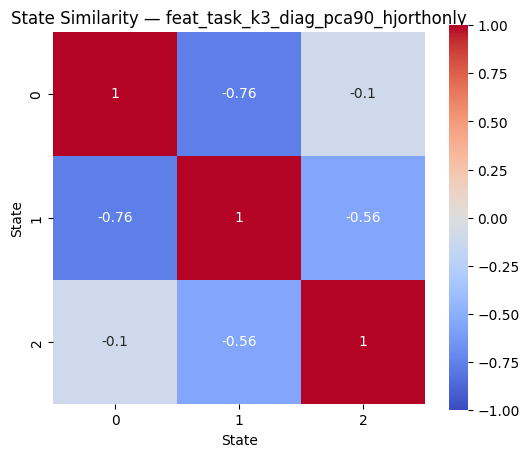

In [4]:
# ============================================================
# BLOQUE 4 — MATRIZ DE SIMILITUD ENTRE ESTADOS
# ============================================================

sim_matrix = cosine_similarity(state_profiles)

print("=" * 60)
print("COSINE SIMILARITY MATRIX")
print("=" * 60)

print(
    np.round(sim_matrix, 4)
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    sim_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    f"State Similarity — {exp_name}"
)

plt.xlabel("State")
plt.ylabel("State")

plt.show()

In [5]:
# ============================================================
# BLOQUE 5 — TABLA DE SEPARABILIDAD
# ============================================================

rows = []

for s in range(n_states):

    similarities = sim_matrix[s].copy()

    similarities[s] = -999

    best_match = np.argmax(similarities)

    rows.append({
        'state': s,
        'most_similar_state': best_match,
        'similarity': similarities[best_match]
    })

df_sep = pd.DataFrame(rows)

print(df_sep)

upper_triangle = sim_matrix[
    np.triu_indices(n_states, k=1)
]

print("\nMean inter-state similarity:")
print(np.mean(upper_triangle))

   state  most_similar_state  similarity
0      0                   2   -0.104319
1      1                   2   -0.561406
2      2                   0   -0.104319

Mean inter-state similarity:
-0.4767283233808921


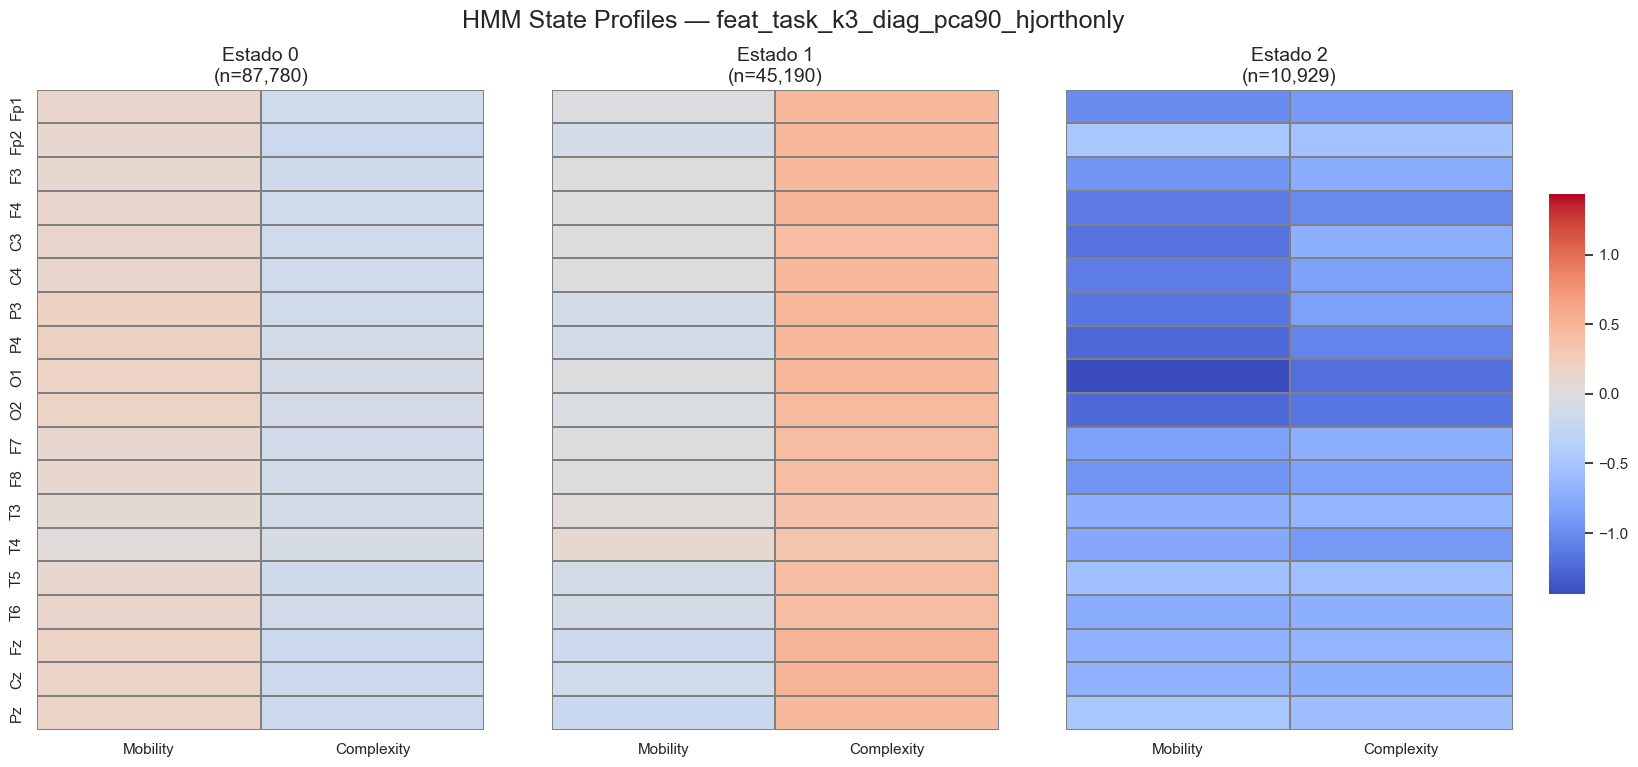

In [6]:
# ============================================================
# BLOQUE 6 — TOPOGRAFÍAS / HEATMAPS
# ============================================================

sns.set_theme(style="white")

# ------------------------------------------------------------
# FEATURES ACTIVAS
# ------------------------------------------------------------

metrics = [
    'Mobility',
    'Complexity'
]

# ------------------------------------------------------------
# CANALES
# ------------------------------------------------------------

ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

n_channels = len(ch_names)

n_metrics = len(metrics)

# ------------------------------------------------------------
# RESHAPE
# ------------------------------------------------------------

state_profiles_3d = np.zeros(
    (n_states, n_channels, n_metrics)
)

for m_idx in range(n_metrics):

    start_col = m_idx * n_channels

    end_col = (m_idx + 1) * n_channels

    state_profiles_3d[:, :, m_idx] = (
        state_profiles[:, start_col:end_col]
    )

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    n_states,
    figsize=(6 * n_states, 8),
    sharey=True
)

if n_states == 1:
    axes = [axes]

global_absmax = np.max(
    np.abs(state_profiles_3d)
)

cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

for s in range(n_states):

    ax = axes[s]

    sns.heatmap(
        state_profiles_3d[s],
        cmap='coolwarm',
        center=0,
        vmin=-global_absmax,
        vmax=global_absmax,
        xticklabels=metrics,
        yticklabels=ch_names,
        linewidths=0.3,
        linecolor='gray',
        ax=ax,
        cbar=(s == 0),
        cbar_ax=None if s > 0 else cbar_ax
    )

    n_windows = np.sum(viterbi_paths == s)

    ax.set_title(
        f"Estado {s}\n(n={n_windows:,})",
        fontsize=14
    )

plt.suptitle(
    f"HMM State Profiles — {exp_name}",
    fontsize=18,
    y=0.98
)

plt.subplots_adjust(
    left=0.08,
    right=0.9,
    top=0.88,
    bottom=0.08,
    wspace=0.15
)

plt.show()

In [8]:
# ============================================================
# BLOQUE 7 — DWELL TIME
# ============================================================

WINDOW_STEP_MS = 100

def get_mean_dwell_time(path, state, step_ms):

    is_s = (path == state)

    if not np.any(is_s):
        return 0.0

    diffs = np.diff(
        np.concatenate(([0], is_s.view(np.int8), [0]))
    )

    starts = np.where(diffs == 1)[0]

    ends = np.where(diffs == -1)[0]

    return np.mean(
        ends - starts
    ) * step_ms

print("=" * 60)
print("DWELL TIMES")
print("=" * 60)

for s in range(n_states):

    dwell = get_mean_dwell_time(
        viterbi_paths,
        s,
        WINDOW_STEP_MS
    )

    print(
        f"State {s}: "
        f"{dwell:.2f} ms"
    )

DWELL TIMES
State 0: 689.17 ms
State 1: 351.73 ms
State 2: 3301.81 ms


In [14]:
# ============================================================
# CARGAR EL HMM CORRECTO + MATRIZ DE TRANSICIÓN
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CARGAR MODELO HMM
# ------------------------------------------------------------

model_path = os.path.join(
    exp_dir,
    f'hmm_model_k{n_states}.pkl'
)

print(f"Cargando modelo desde:\n{model_path}")

model = joblib.load(model_path)

# ------------------------------------------------------------
# MATRIZ DE TRANSICIÓN
# ------------------------------------------------------------

transmat = model.transmat_

print("\n" + "=" * 60)
print("TRANSITION MATRIX")
print("=" * 60)

df_transmat = pd.DataFrame(
    np.round(transmat, 3),
    index=[f"From S{i}" for i in range(n_states)],
    columns=[f"To S{i}" for i in range(n_states)]
)

print(df_transmat)

# ------------------------------------------------------------
# MÉTRICAS DE PERSISTENCIA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE PERSISTENCE")
print("=" * 60)

for s in range(n_states):

    occupancy = np.mean(viterbi_paths == s)

    n_windows = np.sum(viterbi_paths == s)

    self_transition = transmat[s, s]

    print(
        f"""
State {s}
---------
Fractional Occupancy : {occupancy:.4f} ({occupancy*100:.2f}%)
Total Windows        : {n_windows:,}
Self-transition      : {self_transition:.4f}
"""
    )

# ------------------------------------------------------------
# ESTADO MÁS PERSISTENTE
# ------------------------------------------------------------

diag_probs = np.diag(transmat)

most_persistent = np.argmax(diag_probs)

print("=" * 60)
print(f"Most persistent state: State {most_persistent}")
print(f"Self-transition: {diag_probs[most_persistent]:.4f}")
print("=" * 60)

Cargando modelo desde:
c:\Proyectos\eeg_hmm_project\outputs\processed\experiments\feature_hmm\task\feat_task_k3_diag_pca90_hjorthonly\hmm_model_k3.pkl

TRANSITION MATRIX
         To S0  To S1  To S2
From S0  0.842  0.157  0.001
From S1  0.291  0.705  0.005
From S2  0.010  0.022  0.968

STATE PERSISTENCE

State 0
---------
Fractional Occupancy : 0.6100 (61.00%)
Total Windows        : 87,780
Self-transition      : 0.8420


State 1
---------
Fractional Occupancy : 0.3140 (31.40%)
Total Windows        : 45,190
Self-transition      : 0.7048


State 2
---------
Fractional Occupancy : 0.0759 (7.59%)
Total Windows        : 10,929
Self-transition      : 0.9685

Most persistent state: State 2
Self-transition: 0.9685
